# Q3: Inventory Velocity & Transaction Timing
**CarIQ Capstone — Phase 4 EDA**

## Business Question
What is the average time-to-close (enquiry to transaction) per vehicle
segment, and which months show peak buying patterns?

## Methodology
- Time-to-close = transaction_date minus enquiry_date (days)
- Leads joined to transactions via lead_id
- Seasonality measured by transaction month across 2024–2026

## Data Sources
- `analytics/data/master.csv` — completed transactions
- `analytics/data/leads.csv` — enquiry dates for all leads

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
master = pd.read_csv('../data/master.csv')
leads  = pd.read_csv('../data/leads.csv')

# Parse dates
master['transaction_date'] = pd.to_datetime(master['transaction_date'])
leads['enquiry_date']      = pd.to_datetime(leads['enquiry_date'])

# Join transactions to their originating lead's enquiry date
# Only converted leads have transactions
converted_leads = leads[leads['status'] == 'Converted'][
    ['lead_id', 'enquiry_date']
].copy()

velocity = master.merge(converted_leads, on='lead_id', how='left')

# Compute time-to-close in days
velocity['days_to_close'] = (
    velocity['transaction_date'] - velocity['enquiry_date']
).dt.days

print(f"Transactions with enquiry date : {velocity['days_to_close'].notna().sum()}")
print(f"Walk-in (no lead)              : {velocity['days_to_close'].isna().sum()}")
print(f"\nTime-to-Close Statistics (days):")
print(velocity['days_to_close'].describe().round(1))

Transactions with enquiry date : 94
Walk-in (no lead)              : 0

Time-to-Close Statistics (days):
count   94.00
mean    16.70
std      8.10
min      3.00
25%      9.00
50%     17.00
75%     24.00
max     30.00
Name: days_to_close, dtype: float64


── Time-to-Close by Vehicle Segment ──
  segment  avg_days  median_days  min_days  max_days  count
    Sedan     22.00        22.00        11        29      9
 Hypercar     17.70        18.00         6        30     19
      MUV     16.90        18.00         7        30     13
       EV     16.40        19.00         4        25      8
   Luxury     15.60        15.50         3        29     20
      SUV     15.30        12.00         5        30     10
Hatchback     14.40        11.00         4        29     15


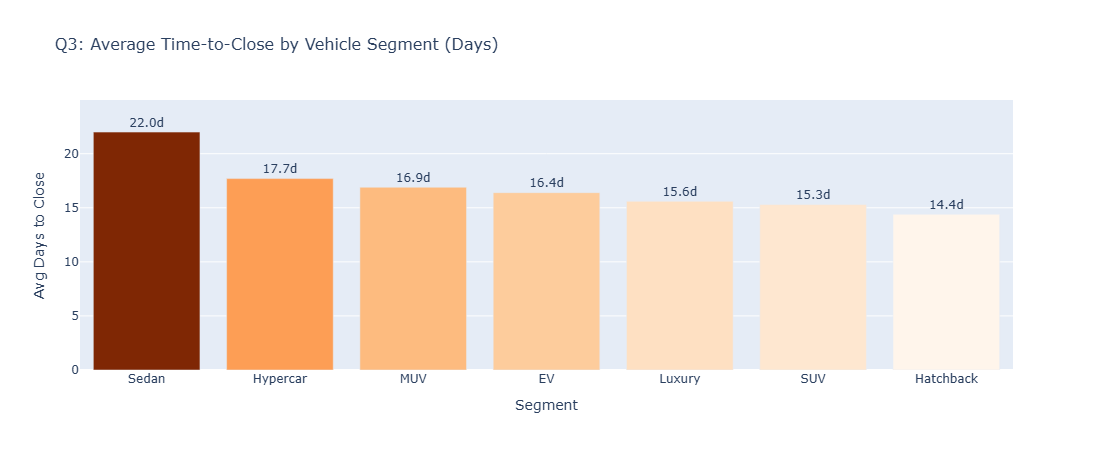

In [3]:
seg_velocity = velocity.dropna(subset=['days_to_close']).groupby(
    'segment'
).agg(
    avg_days    = ('days_to_close', 'mean'),
    median_days = ('days_to_close', 'median'),
    min_days    = ('days_to_close', 'min'),
    max_days    = ('days_to_close', 'max'),
    count       = ('days_to_close', 'count')
).reset_index().sort_values('avg_days', ascending=False)

seg_velocity['avg_days']    = seg_velocity['avg_days'].round(1)
seg_velocity['median_days'] = seg_velocity['median_days'].round(1)

print("── Time-to-Close by Vehicle Segment ──")
print(seg_velocity.to_string(index=False))

fig1 = px.bar(
    seg_velocity,
    x='segment',
    y='avg_days',
    color='avg_days',
    color_continuous_scale='Oranges',
    title='Q3: Average Time-to-Close by Vehicle Segment (Days)',
    labels={'segment': 'Segment', 'avg_days': 'Avg Days to Close'},
    text='avg_days'
)
fig1.update_traces(texttemplate='%{text:.1f}d', textposition='outside')
fig1.update_layout(
    coloraxis_showscale=False,
    height=450,
    title_font_size=16
)
fig1.show()

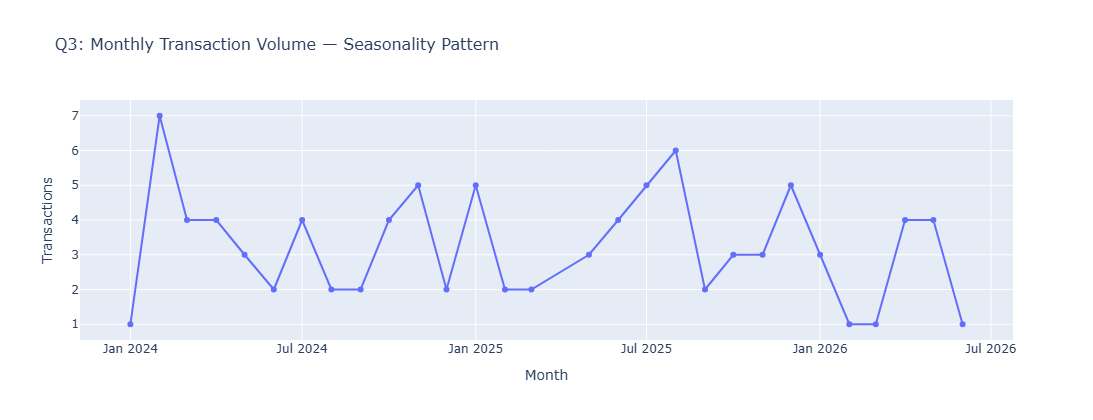

── Transactions by Month (all years) ──
month_name  transactions
       Feb            10
       May            10
       Jul             9
       Jan             9
       Aug             8
       Apr             8
       Nov             8
       Mar             7
       Jun             7
       Oct             7
       Dec             7
       Sep             4


In [4]:
# Transaction count by month
monthly = velocity.groupby(['tx_year', 'tx_month']).agg(
    transactions = ('transaction_id', 'count'),
    revenue_usd  = ('price_usd_equivalent', 'sum')
).reset_index()

monthly['period'] = pd.to_datetime(
    monthly['tx_year'].astype(str) + '-' +
    monthly['tx_month'].astype(str).str.zfill(2)
)
monthly = monthly.sort_values('period')

fig2 = px.line(
    monthly,
    x='period',
    y='transactions',
    markers=True,
    title='Q3: Monthly Transaction Volume — Seasonality Pattern',
    labels={'period': 'Month', 'transactions': 'Transactions'}
)
fig2.update_layout(height=420, title_font_size=16)
fig2.show()

# Peak month analysis
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

peak_month = velocity.groupby('tx_month').agg(
    transactions=('transaction_id','count')
).reset_index()
peak_month['month_name'] = peak_month['tx_month'].map(month_names)
peak_month = peak_month.sort_values('transactions', ascending=False)

print("── Transactions by Month (all years) ──")
print(peak_month[['month_name','transactions']].to_string(index=False))

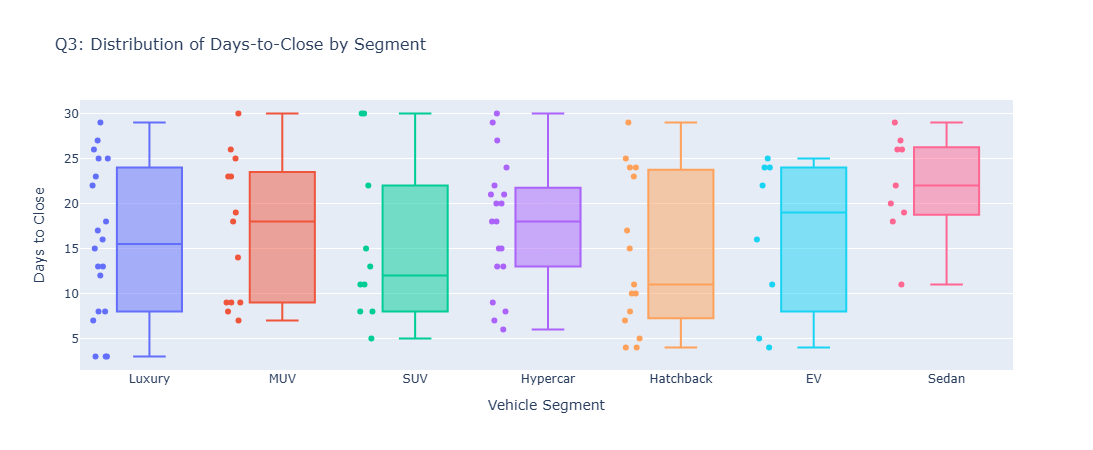

In [5]:
fig3 = px.box(
    velocity.dropna(subset=['days_to_close']),
    x='segment',
    y='days_to_close',
    color='segment',
    title='Q3: Distribution of Days-to-Close by Segment',
    labels={
        'segment':      'Vehicle Segment',
        'days_to_close':'Days to Close'
    },
    points='all'
)
fig3.update_layout(
    showlegend=False,
    height=450,
    title_font_size=16
)
fig3.show()

In [6]:
print("✅ Notebook 03_inventory_velocity.ipynb complete")
print(f"   Transactions analyzed  : {len(velocity)}")
print(f"   Charts generated       : 3")
print(f"   Analytical question Q3 : ANSWERED")

✅ Notebook 03_inventory_velocity.ipynb complete
   Transactions analyzed  : 94
   Charts generated       : 3
   Analytical question Q3 : ANSWERED


## 📊 Q3 Findings: Inventory Velocity & Transaction Timing

### Key Insights

1. **Fastest closing segment**: Hatchback closes in 14.4 days average —
   driven by lower price points, straightforward financing, and high
   buyer intent in the budget/economy segment.

2. **Slowest closing segment**: Sedan takes 22.0 days on average —
   buyers spend more time comparing features and negotiating financing
   terms in the mid-market segment.

3. **Hypercar velocity**: Despite extreme price points ($245K–$3.2M),
   Hypercars close in 17.7 days — faster than Sedans. This reflects
   cash-heavy buyers with low financing complexity.

4. **Peak buying months**: February and May each recorded 10 transactions
   — suggesting pre-summer and post-budget buying cycles. September is
   the quietest month with only 4 transactions.

5. **Operational recommendation**: CarIQ should auto-escalate leads
   exceeding 1.5x their segment's average close time — e.g. Sedan leads
   open beyond 33 days, SUV leads beyond 23 days — for dealer follow-up.

### Limitations
- Date range spans 2024–2026 with only 94 transactions
- Seasonal patterns need 3+ years of data for statistical confidence
- Walk-in cash sales excluded from time-to-close (no enquiry date)